---
---
---

# Summary

---
---
---

<br>

## Dependencies

### Packages

In [1]:
from IPython.display import Image, display
from google.cloud import bigquery
from paddleocr import TextRecognition
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import paddle
import shutil
import sys
import warnings

ROOT_PATH = Path.cwd().resolve()
if ROOT_PATH.name == "notebook":
    ROOT_PATH = ROOT_PATH.parent
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))

from jobs.data_extract import extract_data
from lib import config as the_config
from lib import utils as the_utils

# -------------------------

# Settings
%matplotlib inline
the_config.refresh_logging()
paddle.disable_signal_handler()
warnings.filterwarnings("ignore")

/Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.
/Users/robertovicario/Sviluppo/uninsubria-DATA_SCIENCE/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


### Constants

In [2]:
BQ_CLIENT = bigquery.Client(project=the_config.GCP_PROJECT)

### Paths

In [3]:
for path in the_config.PATHS:
    the_utils.ensure_path(path)

## ETL Pipeline

### Extraction

In [4]:
extract_data(n=1)

2026-07-28 11:56:42.723 | INFO     | jobs.data_extract:extract_data:28 - 

# =========================
# (1) EXTRACTION
# =========================

2026-07-28 11:56:42.724 | DEBUG    | jobs.data_extract:extract_data:60 - [2026-07-28 @ 11:56] [01/19]
2026-07-28 11:56:42.724 | DEBUG    | jobs.data_extract:extract_data:61 - [2026-07-28 @ 11:56] STATION: Bellagio
2026-07-28 11:56:42.847 | SUCCESS  | jobs.data_extract:extract_data:88 - [2026-07-28 @ 11:56] EXTRACTED: bellagio_cernobbio-20260728-1156.png



{'bellagio_cernobbio': {'city': 'Bellagio',
  'province': 'Como',
  'latitude': 45.9872549,
  'longitude': 9.2613001,
  'altitude_m': 685}}

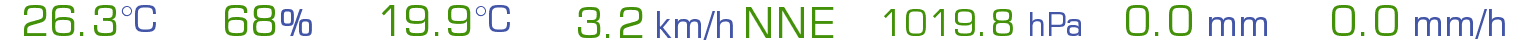

In [5]:
files = list(the_config.TMP_IMG_PATH.iterdir())
filename = files[0]
display(Image(filename=str(filename)))

### Transformation

In [6]:
# [!]
img_cv = cv2.imread(str(filename))
img_cv = cv2.resize(
    img_cv,
    None,
    fx=2,
    fy=2,
    interpolation=cv2.INTER_LINEAR
)

hsv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2HSV)
green_mask = cv2.inRange(
    hsv,
    np.array([35, 50, 50]),
    np.array([85, 255, 255]),
)
green = np.full_like(green_mask, 255)
green[green_mask > 0] = 0
blue_mask = cv2.inRange(
    hsv,
    np.array([90, 50, 50]),
    np.array([130, 255, 255]),
)
blue = np.full_like(blue_mask, 255)
blue[blue_mask > 0] = 0

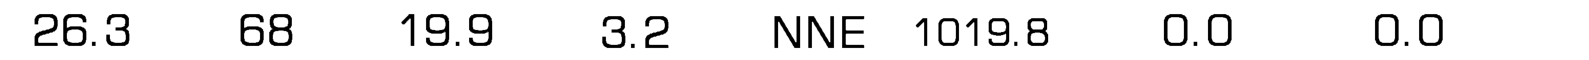

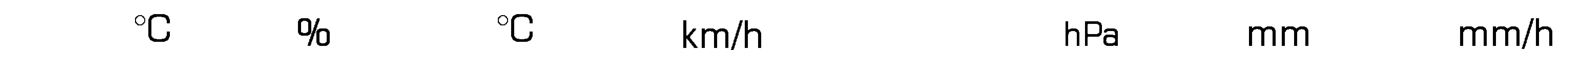

In [7]:
plt.figure(figsize=(16, 4))
plt.imshow(green, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
plt.imshow(blue, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# [!]
green_rois = the_utils.extract_rois(img_cv, green_mask, "green")
blue_rois  = the_utils.extract_rois(img_cv, blue_mask, "blue")
all_rois = sorted(green_rois + blue_rois, key=lambda r: r["bbox"][0])

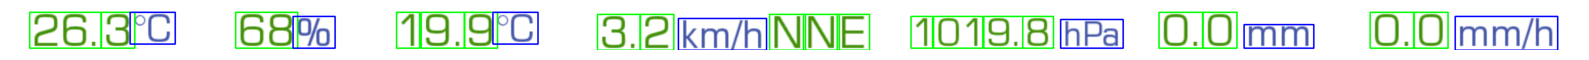

In [9]:
debug = img_cv.copy()
green_idx = 1
blue_idx = 1

for roi in all_rois:

    x1, y1, x2, y2 = roi["bbox"]
    if roi["type"] == "green":
        box_color = (0, 255, 0)
        letter = "G"
        idx = green_idx
        green_idx += 1
    else:
        box_color = (255, 0, 0)
        letter = "B"
        idx = blue_idx
        blue_idx += 1

    cv2.rectangle(debug, (x1, y1), (x2, y2), box_color, 2)
    (letter_w, letter_h), _ = cv2.getTextSize(
		letter,
		cv2.FONT_HERSHEY_SIMPLEX,
		1.4,
		3
	)
    (label_w, label_h), baseline = cv2.getTextSize(
		f"{letter}{idx}",
		cv2.FONT_HERSHEY_SIMPLEX,
		1.4,
		3
	)

plt.figure(figsize=(16, 4))
plt.imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
# [!]
pieces = the_utils.get_pieces(img_cv, green_mask, all_rois)

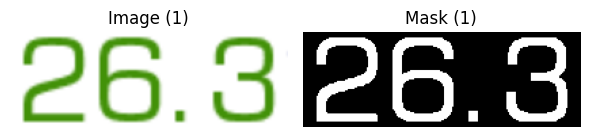

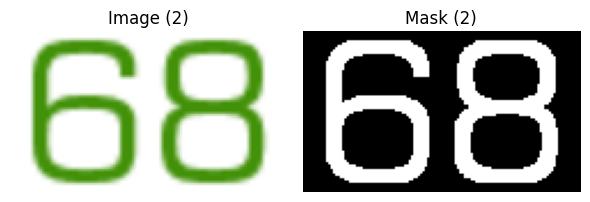

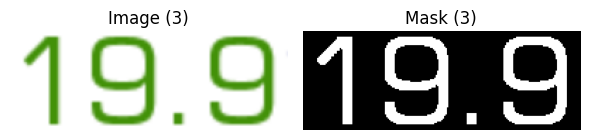

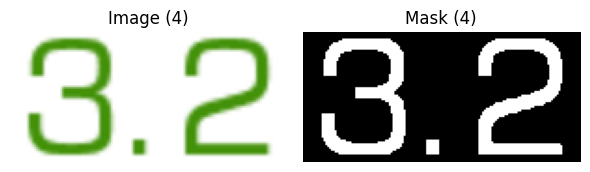

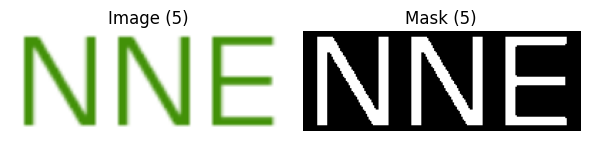

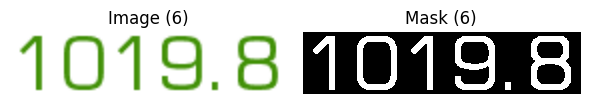

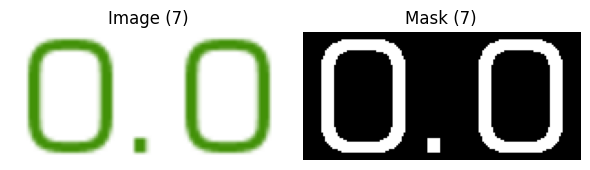

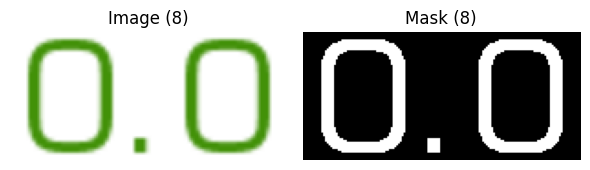

In [11]:
for i, piece in enumerate(pieces, start=1):

    fig, axes = plt.subplots(1, 2, figsize=(6, 4))
    axes[0].imshow(cv2.cvtColor(piece["image"], cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Image ({i})")
    axes[0].axis("off")
    axes[1].imshow(piece["green_mask"], cmap="gray")
    axes[1].set_title(f"Mask ({i})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [12]:
# [!]
MODEL_OCR = TextRecognition(
    model_name=the_config.OCR_MODEL,
    device=the_config.DEVICE
)

Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/robertovicario/.paddlex/official_models/PP-OCRv5_server_rec`.


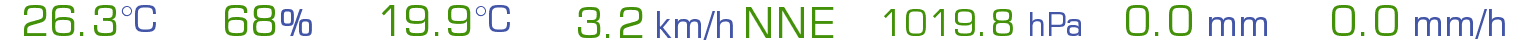

2026-07-28 11:56:44.139 | DEBUG    | lib.utils:ocr_predict:165 -  temperature_c:   26.3 (confidence=0.999)
2026-07-28 11:56:44.208 | DEBUG    | lib.utils:ocr_predict:165 -   humidity_pct:     68 (confidence=1.000)
2026-07-28 11:56:44.277 | DEBUG    | lib.utils:ocr_predict:165 -    dew_point_c:   19.9 (confidence=1.000)
2026-07-28 11:56:44.345 | DEBUG    | lib.utils:ocr_predict:165 - wind_speed_kmh:    3.2 (confidence=0.999)
2026-07-28 11:56:44.413 | DEBUG    | lib.utils:ocr_predict:165 -       wind_dir:    NNE (confidence=0.999)
2026-07-28 11:56:44.481 | DEBUG    | lib.utils:ocr_predict:165 -   pressure_hpa: 1019.8 (confidence=1.000)
2026-07-28 11:56:44.548 | DEBUG    | lib.utils:ocr_predict:165 -        rain_mm:    0.0 (confidence=0.991)
2026-07-28 11:56:44.616 | DEBUG    | lib.utils:ocr_predict:165 -       rain_mmh:    0.0 (confidence=0.991)


In [13]:
display(Image(filename))

# [!]
values = the_utils.ocr_predict(
    MODEL_OCR,
    the_config.OCR_FIELDS,
    pieces,
    verbose=True
)

### Loading

In [14]:
query = f"""
SELECT * FROM `{the_config.BQ_TABLE}`;
"""
df = BQ_CLIENT.query(query).to_dataframe()
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 19 non-null     dbdate 
 1   year                 19 non-null     Int64  
 2   month                19 non-null     Int64  
 3   day                  19 non-null     Int64  
 4   hour                 19 non-null     Int64  
 5   minute               19 non-null     Int64  
 6   quarter              19 non-null     Int64  
 7   week_of_year         19 non-null     Int64  
 8   day_of_year          19 non-null     Int64  
 9   day_of_week          19 non-null     Int64  
 10  station              19 non-null     str    
 11  city                 19 non-null     str    
 12  province             19 non-null     str    
 13  latitude             19 non-null     float64
 14  longitude            19 non-null     float64
 15  altitude_m           19 non-null     float64
 16  tem

None

In [15]:
# [!]
shutil.rmtree(the_config.TMP_IMG_PATH)